### Outlier Detection and Handling

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] =  le.fit_transform(df['Sex'])
df['ExerciseAngina'] =  le.fit_transform(df['ExerciseAngina'])

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0


In [5]:
cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]

df_encoded = pd.get_dummies(
    df,
    columns= cat_cols,
    dtype=int
)

df_encoded.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1


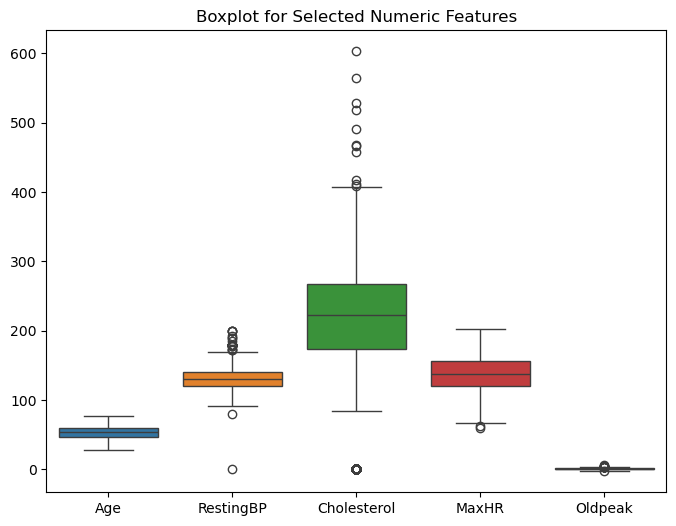

In [6]:
numeric_col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

plt.figure(figsize=(8,6))
sns.boxplot(data=df_encoded[numeric_col])
plt.title("Boxplot for Selected Numeric Features")
plt.show()

##### Outlier Detection

In [7]:
# Using IQR on Cholesterol for outliers
col = "Cholesterol"

Q1 = df_encoded[col].quantile(.25)
Q3 = df_encoded[col].quantile(.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_encoded[(df_encoded[col]<lower) | (df_encoded[col]>upper)]
print(f"Number of outliers detected is {col} : ",len(outliers))

Number of outliers detected is Cholesterol :  183


In [8]:
# # Using IQR on RestingBP for outliers
# col = "RestingBP"

# Q1 = df_encoded[col].quantile(.25)
# Q3 = df_encoded[col].quantile(.75)

# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# outliers = df_encoded[(df_encoded[col]<lower) | (df_encoded[col]>upper)]
# print(f"Number of outliers detected is {col} : ",len(outliers))

In [9]:
# # Using IQR on OldPeak for outliers
# col = "Oldpeak"

# Q1 = df_encoded[col].quantile(.25)
# Q3 = df_encoded[col].quantile(.75)

# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# outliers = df_encoded[(df_encoded[col]<lower) | (df_encoded[col]>upper)]
# print(f"Number of outliers detected is {col} : ",len(outliers))

##### Outlier Handle

In [10]:
# Remove Outliers
df_no_outliers = df_encoded[(df_encoded[col]>=lower) & (df_encoded[col]<=upper)]
print(len(df_no_outliers))

735


In [11]:
# Cap outliers
df_capped = df_encoded.copy()
df_capped[col] = df_capped[col].clip(lower, upper)   ## Lower er nicer value gula lower diye replace hoye jabe, upper er uporer value gula upper diye replace hye jbe

df_capped

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289.0,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180.0,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283.0,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214.0,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195.0,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264.0,0,132,0,1.2,1,0,0,0,1,0,1,0,0,1,0
914,68,1,144,193.0,1,141,0,3.4,1,1,0,0,0,0,1,0,0,1,0
915,57,1,130,131.0,0,115,1,1.2,1,1,0,0,0,0,1,0,0,1,0
916,57,0,130,236.0,0,174,0,0.0,1,0,1,0,0,1,0,0,0,1,0


In [12]:
# Log transformation  => Outliers k log value er maddhome ekta range er mddhe niye ase
df_log = df_encoded.copy()
df_log[col+"_log"] = np.log(df_log[col] + 1)

df_log

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Cholesterol_log
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1,5.669881
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0,5.198497
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1,5.648974
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0,5.370638
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1,5.278115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,0,1.2,1,0,0,0,1,0,1,0,0,1,0,5.579730
914,68,1,144,193,1,141,0,3.4,1,1,0,0,0,0,1,0,0,1,0,5.267858
915,57,1,130,131,0,115,1,1.2,1,1,0,0,0,0,1,0,0,1,0,4.882802
916,57,0,130,236,0,174,0,0.0,1,0,1,0,0,1,0,0,0,1,0,5.468060


### Feature Transformation and Domain-Driven Features

In [13]:
from sklearn.preprocessing import PolynomialFeatures

In [14]:
#Polynomial Features using Age and MaxHR
poly_cols = ['Age','MaxHR']
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df_encoded[poly_cols])
poly_features_names = poly.get_feature_names_out(poly_cols)

print(poly_features_names)
print(poly_features.shape)

['Age' 'MaxHR' 'Age^2' 'Age MaxHR' 'MaxHR^2']
(918, 5)


In [20]:
# Binnig is transforming continuous datapoints into categorical datapoints
# Binning => Age into categories (Young, Middle, Old)  
df_encoded['Age_Bin'] = pd.cut(
    df_encoded['Age'],
    bins=[0,30,50,100],
    labels=['Young','Middle','Old']
)

display(df_encoded[['Age','Age_Bin']].head(30))

,Age,Age_Bin
0,40,Middle
1,49,Middle
2,37,Middle
3,48,Middle
4,54,Old
5,39,Middle
6,45,Middle
7,54,Old
8,37,Middle
9,48,Middle


In [24]:
# Domain-driven risk categories: for RestingBP and Oldpeak
def bp_risk(bp):
    if bp<120:
        return "Normal"
    elif bp<140:
        return "Elevated"
    else:
        return "High"

def oldpeak_risk(op):
    if op == 0:
        return "No Stress"
    elif op < 2:
        return "Moderate Stress"
    else:
        return "High Stress"
    
df_encoded['BP_Risk'] = df_encoded['RestingBP'].apply(bp_risk)
df_encoded['Oldpeak_Risk'] = df_encoded['Oldpeak'].apply(oldpeak_risk)

df_encoded[['RestingBP', 'BP_Risk','Oldpeak', 'Oldpeak_Risk']]

,RestingBP,BP_Risk,Oldpeak,Oldpeak_Risk
0,140,High,0.0,No Stress
1,160,High,1.0,Moderate Stress
2,130,Elevated,0.0,No Stress
3,138,Elevated,1.5,Moderate Stress
4,150,High,0.0,No Stress
...,...,...,...,...
913,110,Normal,1.2,Moderate Stress
914,144,High,3.4,High Stress
915,130,Elevated,1.2,Moderate Stress
916,130,Elevated,0.0,No Stress


In [25]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = ['Age','RestingBP','Cholesterol', 'MaxHR', 'Oldpeak']
cat_features = ['Sex','ExerciseAngina', 'ChestPainType','RestingECG','ST_Slope']

#Numeric Pipeline
num_pipeline = Pipeline(
    [('scaler', StandardScaler())]
)

# Categorical Pipeline
cat_pipeline = Pipeline([
    ('ohe',OneHotEncoder(drop='first'))
])


# Combine Both
preprocess = ColumnTransformer([
    ('num',num_pipeline,num_features),
    ('cat',cat_pipeline,cat_features)
])

# Full pipeline with simple model
clf = Pipeline([
    ('prep',preprocess),
    ('model',LogisticRegression(max_iter=1000))
])

### Quick Sanity Check with Simple Model

In [26]:
# Train-test split using Original df(Not already encoded)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
target_col = "HeartDisease"
X = df.drop(columns=[target_col])
y = df[target_col]

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe =  train_test_split(
    X,y, test_size=.25,random_state=42
)

# Fit the full pipeline
clf.fit(X_train_pipe,y_train_pipe)

# Predict and evaluate
y_pred_pipe = clf.predict(X_test_pipe)
acc = accuracy_score(y_test_pipe,y_pred_pipe)

print("Logistic Regression with preprocessing pipeline: ",acc)


Logistic Regression with preprocessing pipeline:  0.8434782608695652
